In [1]:
import pandas as pd

df = pd.read_csv("malaysia_house_price_data_2025_cleaned.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (2318, 8)


In [2]:
X = df[['Area', 'State', 'Tenure', 'Type', 'Median_PSF', 'Transactions']]
y = df['Median_Price']

print("Features (X):", X.columns.tolist())
print("Target   (y):", y.name)
print()
print("X shape:", X.shape)
print("y shape:", y.shape)

Features (X): ['Area', 'State', 'Tenure', 'Type', 'Median_PSF', 'Transactions']
Target   (y): Median_Price

X shape: (2318, 6)
y shape: (2318,)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print()
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (1854, 6)
y_train: (1854,)

X_test: (464, 6)
y_test: (464,)


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ['Area', 'State', 'Tenure', 'Type']

numerical_features = ['Median_PSF', 'Transactions']

preprocessor = ColumnTransformer(
    transformers=[('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
                  ('numerical', 'passthrough', numerical_features)]
)

print("Preprocessor created")
print("Categorical features:", categorical_features)
print("Numerical features  :", numerical_features)

Preprocessor created
Categorical features: ['Area', 'State', 'Tenure', 'Type']
Numerical features  : ['Median_PSF', 'Transactions']


In [5]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Original  X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_processed.shape)
print()
print("Original  X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_processed.shape)

Original  X_train shape: (1854, 6)
Processed X_train shape: (1854, 314)

Original  X_test shape: (464, 6)
Processed X_test shape: (464, 314)


In [6]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
import numpy as np

In [7]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train)
y_pred_linear = linear_model.predict(X_test_processed)

print("Linear Regression training completed.")
print("Number of predictions:", len(y_pred_linear))

Linear Regression training completed.
Number of predictions: 464


In [8]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test,y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("====================================")
print("Linear Regression Results")
print("====================================")
print("MAE :", mae_linear)
print("MSE :", mse_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)
print("====================================")

Linear Regression Results
MAE : 119508.60620423318
MSE : 29655330866.025364
RMSE: 172207.23232787108
R²  : 0.7466705992633571


In [9]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train_processed, y_train)
y_pred_tree = tree_model.predict(X_test_processed)

print("Decision Tree Regression training completed.")
print("Number of predictions:", len(y_pred_tree))

Decision Tree Regression training completed.
Number of predictions: 464


In [10]:
mae_tree = mean_absolute_error(y_test,y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("====================================")
print("Decision Tree Results")
print("====================================")
print("MAE :", mae_tree)
print("MSE :", mse_tree)
print("RMSE:", rmse_tree)
print("R²  :", r2_tree)
print("====================================")

Decision Tree Results
MAE : 118833.1260775862
MSE : 40899664847.957436
RMSE: 202236.65554977275
R²  : 0.6506163551817667


In [11]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(random_state=42, n_jobs=-1)
random_forest_model.fit(X_train_processed,y_train)
y_pred_rf = random_forest_model.predict(X_test_processed)

print("Random Forest Regression training completed.")
print("Number of predictions:", len(y_pred_rf))

Random Forest Regression training completed.
Number of predictions: 464


In [12]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(y_test, y_pred_rf)

print("====================================")
print("Random Forest Results")
print("====================================")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)
print("====================================")

Random Forest Results
MAE : 100097.34193965516
MSE : 23052679652.55088
RMSE: 151831.08921611172
R²  : 0.8030734660106247


In [13]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting_model = GradientBoostingRegressor(random_state=42)
gradient_boosting_model.fit(X_train_processed, y_train)
y_pred_gb = gradient_boosting_model.predict( X_test_processed)

print("Gradient Boosting Regression training completed.")
print("Number of predictions:", len(y_pred_gb))

Gradient Boosting Regression training completed.
Number of predictions: 464


In [14]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("====================================")
print("Gradient Boosting Results")
print("====================================")
print("MAE :", mae_gb)
print("MSE :", mse_gb)
print("RMSE:", rmse_gb)
print("R²  :", r2_gb)
print("====================================")

Gradient Boosting Results
MAE : 104464.60136235421
MSE : 24326066778.318905
RMSE: 155968.1595016076
R²  : 0.7921956107294299


In [15]:
from sklearn.model_selection import GridSearchCV

In [16]:
linear_param_grid = {
    'fit_intercept': [True, False]
}

linear_grid = GridSearchCV(
    estimator=LinearRegression(),
    param_grid=linear_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

linear_grid.fit(X_train_processed, y_train)

print("====================================")
print("Linear Regression GridSearchCV")
print("====================================")
print("Best Parameters:", linear_grid.best_params_)
print("Best CV R²:", linear_grid.best_score_)
print("====================================")

Linear Regression GridSearchCV
Best Parameters: {'fit_intercept': False}
Best CV R²: 0.6843814861653217


In [17]:
tuned_linear_model = linear_grid.best_estimator_

y_pred_tuned_linear = tuned_linear_model.predict(X_test_processed)

mae_tuned_linear = mean_absolute_error(y_test, y_pred_tuned_linear)
mse_tuned_linear = mean_squared_error(y_test, y_pred_tuned_linear)
rmse_tuned_linear = np.sqrt(mse_tuned_linear)
r2_tuned_linear = r2_score(y_test, y_pred_tuned_linear)

print("====================================")
print("Tuned Linear Regression Results")
print("====================================")
print("MAE :", mae_tuned_linear)
print("MSE :", mse_tuned_linear)
print("RMSE:", rmse_tuned_linear)
print("R²  :", r2_tuned_linear)
print("====================================")

Tuned Linear Regression Results
MAE : 119585.76277225
MSE : 29638393267.552723
RMSE: 172158.04735054568
R²  : 0.7468152879768426


In [18]:
tree_param_grid = {
    'max_depth': [None, 5, 8, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

tree_grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=tree_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

tree_grid.fit(X_train_processed, y_train)

print("====================================")
print("Decision Tree GridSearchCV")
print("====================================")
print("Best Parameters:", tree_grid.best_params_)
print("Best CV R²:", tree_grid.best_score_)
print("====================================")

Decision Tree GridSearchCV
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV R²: 0.6874128788693727


In [19]:
tuned_tree_model = tree_grid.best_estimator_

y_pred_tuned_tree = tuned_tree_model.predict(X_test_processed)

mae_tuned_tree = mean_absolute_error(y_test, y_pred_tuned_tree)
mse_tuned_tree = mean_squared_error(y_test, y_pred_tuned_tree)
rmse_tuned_tree = np.sqrt(mse_tuned_tree)
r2_tuned_tree = r2_score(y_test, y_pred_tuned_tree)

print("====================================")
print("Tuned Decision Tree Results")
print("====================================")
print("MAE :", mae_tuned_tree)
print("MSE :", mse_tuned_tree)
print("RMSE:", rmse_tuned_tree)
print("R²  :", r2_tuned_tree)
print("====================================")

Tuned Decision Tree Results
MAE : 109697.50982546489
MSE : 30146240324.883327
RMSE: 173626.7269889153
R²  : 0.742477026121642


In [20]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rf_grid.fit(X_train_processed, y_train)

print("====================================")
print("Random Forest GridSearchCV")
print("====================================")
print("Best Parameters:", rf_grid.best_params_)
print("Best CV R²:", rf_grid.best_score_)
print("====================================")

Random Forest GridSearchCV
Best Parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R²: 0.7469724218781277


In [21]:
tuned_rf_model = rf_grid.best_estimator_

y_pred_tuned_rf = tuned_rf_model.predict(X_test_processed)

mae_tuned_rf = mean_absolute_error(y_test, y_pred_tuned_rf)
mse_tuned_rf = mean_squared_error(y_test, y_pred_tuned_rf)
rmse_tuned_rf = np.sqrt(mse_tuned_rf)
r2_tuned_rf = r2_score(y_test, y_pred_tuned_rf)

print("====================================")
print("Tuned Random Forest Results")
print("====================================")
print("MAE :", mae_tuned_rf)
print("MSE :", mse_tuned_rf)
print("RMSE:", rmse_tuned_rf)
print("R²  :", r2_tuned_rf)
print("====================================")

Tuned Random Forest Results
MAE : 99594.33934667046
MSE : 22850174511.657497
RMSE: 151162.74181046564
R²  : 0.80480335755088


In [22]:
gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

gb_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=gb_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

gb_grid.fit(X_train_processed, y_train)

print("====================================")
print("Gradient Boosting GridSearchCV")
print("====================================")
print("Best Parameters:", gb_grid.best_params_)
print("Best CV R²:", gb_grid.best_score_)
print("====================================")

Gradient Boosting GridSearchCV
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV R²: 0.7557354822307627


In [23]:
tuned_gb_model = gb_grid.best_estimator_

y_pred_tuned_gb = tuned_gb_model.predict(X_test_processed)

mae_tuned_gb = mean_absolute_error(y_test, y_pred_tuned_gb)
mse_tuned_gb = mean_squared_error(y_test, y_pred_tuned_gb)
rmse_tuned_gb = np.sqrt(mse_tuned_gb)
r2_tuned_gb = r2_score(y_test, y_pred_tuned_gb)

print("====================================")
print("Tuned Gradient Boosting Results")
print("====================================")
print("MAE :", mae_tuned_gb)
print("MSE :", mse_tuned_gb)
print("RMSE:", rmse_tuned_gb)
print("R²  :", r2_tuned_gb)
print("====================================")

Tuned Gradient Boosting Results
MAE : 99751.91934435673
MSE : 22989857881.131046
RMSE: 151624.06761834034
R²  : 0.8036101183170481


In [24]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],

    'Before MAE': [
        mae_linear,
        mae_tree,
        mae_rf,
        mae_gb
    ],

    'After MAE': [
        mae_tuned_linear,
        mae_tuned_tree,
        mae_tuned_rf,
        mae_tuned_gb
    ],

    'MAE Improvement': [
        mae_linear - mae_tuned_linear,
        mae_tree - mae_tuned_tree,
        mae_rf - mae_tuned_rf,
        mae_gb - mae_tuned_gb
    ],

    'Before RMSE': [
        rmse_linear,
        rmse_tree,
        rmse_rf,
        rmse_gb
    ],

    'After RMSE': [
        rmse_tuned_linear,
        rmse_tuned_tree,
        rmse_tuned_rf,
        rmse_tuned_gb
    ],

    'RMSE Improvement': [
        rmse_linear - rmse_tuned_linear,
        rmse_tree - rmse_tuned_tree,
        rmse_rf - rmse_tuned_rf,
        rmse_gb - rmse_tuned_gb
    ],

    'Before R²': [
        r2_linear,
        r2_tree,
        r2_rf,
        r2_gb
    ],

    'After R²': [
        r2_tuned_linear,
        r2_tuned_tree,
        r2_tuned_rf,
        r2_tuned_gb
    ],

    'R² Improvement': [
        r2_tuned_linear - r2_linear,
        r2_tuned_tree - r2_tree,
        r2_tuned_rf - r2_rf,
        r2_tuned_gb - r2_gb
    ]
})

display(comparison)

,Model,Before MAE,After MAE,MAE Improvement,Before RMSE,After RMSE,RMSE Improvement,Before R²,After R²,R² Improvement
0,Linear Regression,119508.606204,119585.762772,-77.156568,172207.232328,172158.047351,49.184977,0.746671,0.746815,0.000145
1,Decision Tree,118833.126078,109697.509825,9135.616252,202236.655550,173626.726989,28609.928561,0.650616,0.742477,0.091861
2,Random Forest,100097.341940,99594.339347,503.002593,151831.089216,151162.741810,668.347406,0.803073,0.804803,0.001730
3,Gradient Boosting,104464.601362,99751.919344,4712.682018,155968.159502,151624.067618,4344.091883,0.792196,0.803610,0.011415


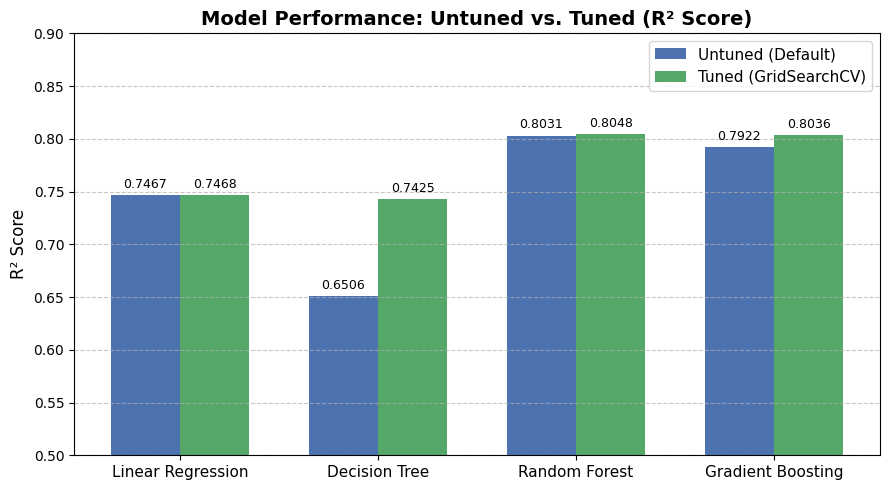

In [25]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']
before_r2 = [r2_linear, r2_tree, r2_rf, r2_gb]
after_r2 = [r2_tuned_linear, r2_tuned_tree, r2_tuned_rf, r2_tuned_gb]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
rects1 = ax.bar(x - width/2, before_r2, width, label='Untuned (Default)', color='#4c72b0')
rects2 = ax.bar(x + width/2, after_r2, width, label='Tuned (GridSearchCV)', color='#55a868')

ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Model Performance: Untuned vs. Tuned (R² Score)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0.5, 0.9)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)

for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()

plt.tight_layout()
plt.savefig(
    'model_performance_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


In [26]:
final_comparison = pd.DataFrame({
    'Model': [
        'Tuned Linear Regression',
        'Tuned Decision Tree',
        'Tuned Random Forest',
        'Tuned Gradient Boosting'
    ],

    'MAE': [
        mae_tuned_linear,
        mae_tuned_tree,
        mae_tuned_rf,
        mae_tuned_gb
    ],

    'RMSE': [
        rmse_tuned_linear,
        rmse_tuned_tree,
        rmse_tuned_rf,
        rmse_tuned_gb
    ],

    'R²': [
        r2_tuned_linear,
        r2_tuned_tree,
        r2_tuned_rf,
        r2_tuned_gb
    ]
})

display(final_comparison)

,Model,MAE,RMSE,R²
0,Tuned Linear Regression,119585.762772,172158.047351,0.746815
1,Tuned Decision Tree,109697.509825,173626.726989,0.742477
2,Tuned Random Forest,99594.339347,151162.741810,0.804803
3,Tuned Gradient Boosting,99751.919344,151624.067618,0.803610


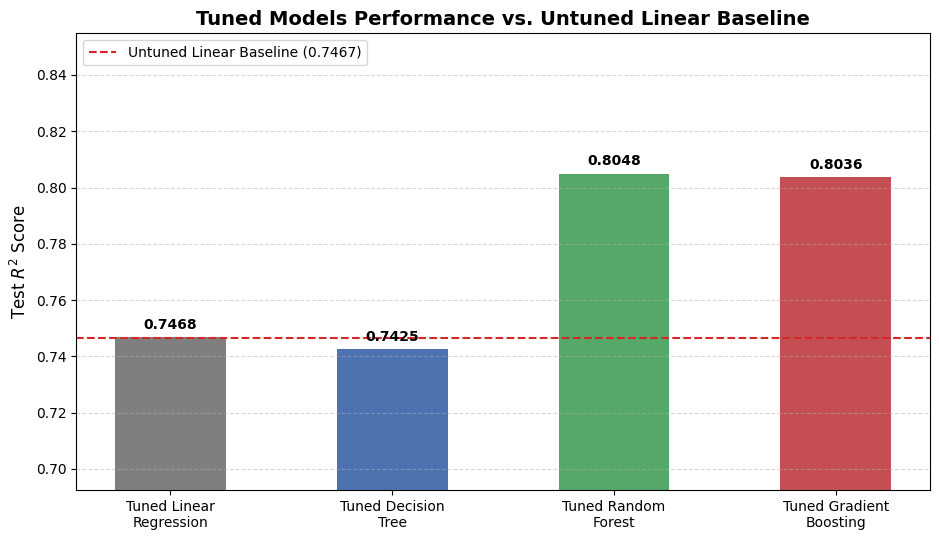

In [27]:
models = [
    "Tuned Linear\nRegression",
    "Tuned Decision\nTree",
    "Tuned Random\nForest",
    "Tuned Gradient\nBoosting",
]
test_r2 = [r2_tuned_linear, r2_tuned_tree, r2_tuned_rf, r2_tuned_gb]

colors = ["#7f7f7f", "#4c72b0", "#55a868", "#c44e52"]

fig, ax = plt.subplots(figsize=(9.5, 5.5))
bars = ax.bar(models, test_r2, color=colors, width=0.5)

original_baseline_val = r2_linear
ax.axhline(
    y=original_baseline_val,
    color="#d62728",
    linestyle="--",
    linewidth=1.5,
    label=f"Untuned Linear Baseline ({original_baseline_val:.4f})",
)

ax.set_ylabel("Test $R^2$ Score", fontsize=12)
ax.set_title(
    "Tuned Models Performance vs. Untuned Linear Baseline",
    fontsize=14,
    fontweight="bold",
)

all_vals = test_r2 + [original_baseline_val]
ax.set_ylim(min(all_vals) - 0.05, max(all_vals) + 0.05)

ax.legend(loc="upper left", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{height:.4f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig("final_benchmark.png", dpi=300, bbox_inches="tight")
plt.show()

In [28]:
y_train_tuned_linear = tuned_linear_model.predict(X_train_processed)
y_train_tuned_tree = tuned_tree_model.predict(X_train_processed)
y_train_tuned_rf = tuned_rf_model.predict(X_train_processed)
y_train_tuned_gb = tuned_gb_model.predict(X_train_processed)

r2_train_tuned_linear = r2_score(y_train, y_train_tuned_linear)
r2_train_tuned_tree = r2_score(y_train, y_train_tuned_tree)
r2_train_tuned_rf = r2_score(y_train, y_train_tuned_rf)
r2_train_tuned_gb = r2_score(y_train, y_train_tuned_gb)

overfitting_comparison = pd.DataFrame({
    'Model': [
        'Tuned Linear Regression',
        'Tuned Decision Tree',
        'Tuned Random Forest',
        'Tuned Gradient Boosting'
    ],

    'Train R²': [
        r2_train_tuned_linear,
        r2_train_tuned_tree,
        r2_train_tuned_rf,
        r2_train_tuned_gb
    ],

    'Test R²': [
        r2_tuned_linear,
        r2_tuned_tree,
        r2_tuned_rf,
        r2_tuned_gb
    ],

    'R² Gap': [
        r2_train_tuned_linear - r2_tuned_linear,
        r2_train_tuned_tree - r2_tuned_tree,
        r2_train_tuned_rf - r2_tuned_rf,
        r2_train_tuned_gb - r2_tuned_gb
    ]
})

display(overfitting_comparison)

,Model,Train R²,Test R²,R² Gap
0,Tuned Linear Regression,0.770429,0.746815,0.023614
1,Tuned Decision Tree,0.823419,0.742477,0.080942
2,Tuned Random Forest,0.948370,0.804803,0.143567
3,Tuned Gradient Boosting,0.874805,0.803610,0.071195


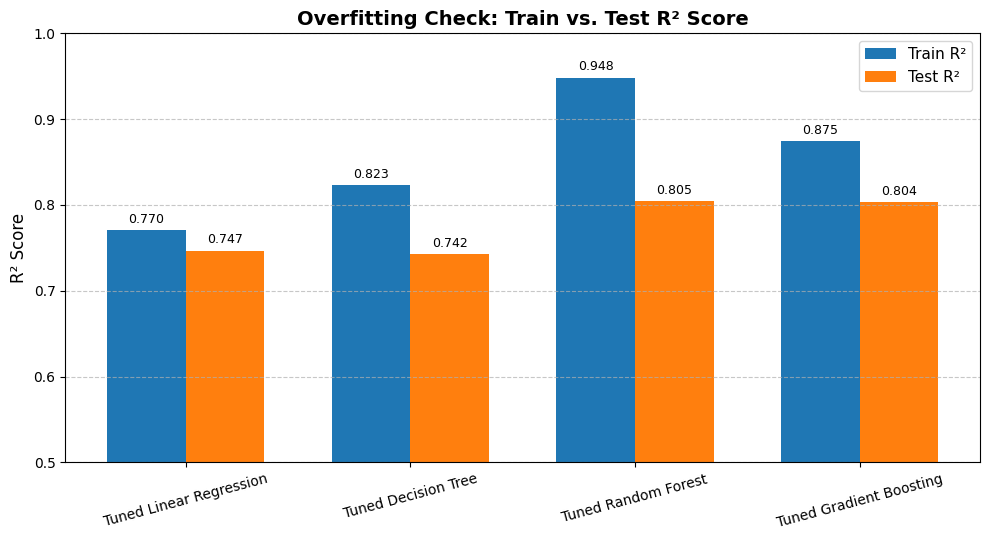

In [29]:
models_of = overfitting_comparison['Model']
train_r2 = overfitting_comparison['Train R²']
test_r2 = overfitting_comparison['Test R²']

x = np.arange(len(models_of))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5.5))
rects1 = ax.bar(x - width/2, train_r2, width, label='Train R²', color='#1f77b4')
rects2 = ax.bar(x + width/2, test_r2, width, label='Test R²', color='#ff7f0e')

ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Overfitting Check: Train vs. Test R² Score', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_of, rotation=15, fontsize=10)
ax.set_ylim(0.5, 1.0)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)

for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(
    'overfitting_comparison.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

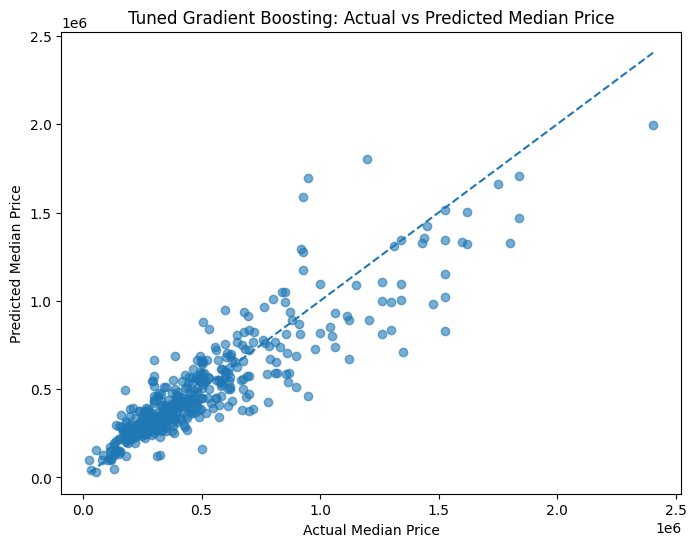

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_tuned_gb,
    alpha=0.6
)

# Perfect prediction line
min_price = min(y_test.min(), y_pred_tuned_gb.min())
max_price = max(y_test.max(), y_pred_tuned_gb.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle='--'
)

plt.xlabel("Actual Median Price")
plt.ylabel("Predicted Median Price")
plt.title("Tuned Gradient Boosting: Actual vs Predicted Median Price")
plt.savefig(
    'tuned_gradient_boosting_actual_predicted.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

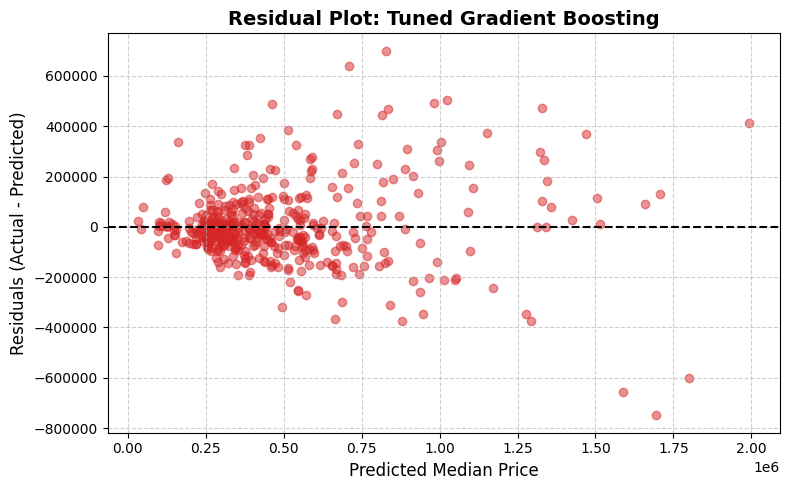

In [31]:
residuals = y_test - y_pred_tuned_gb

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_tuned_gb, residuals, alpha=0.5, color='#d62728')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
plt.xlabel('Predicted Median Price', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.title('Residual Plot: Tuned Gradient Boosting', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(
    'residual_plot_tuned_gradient_boosting.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

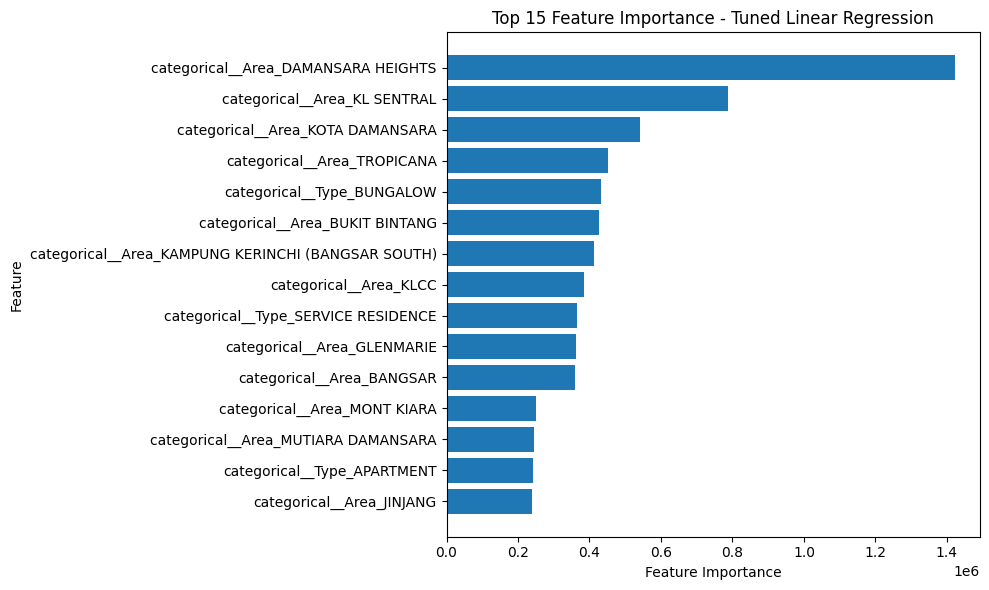

In [32]:
feature_names = preprocessor.get_feature_names_out()
feature_importance = np.abs(tuned_linear_model.coef_)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

top_features = importance_df.head(15).sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance - Tuned Linear Regression")

plt.tight_layout()

plt.savefig(
    'top_feature_tuned_linear_regression.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

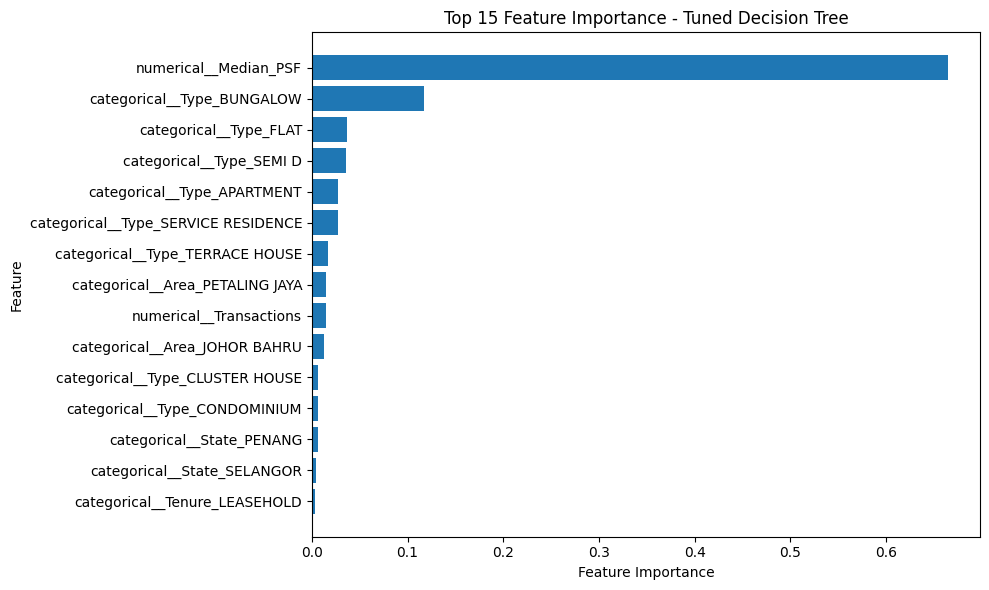

In [33]:
feature_names = preprocessor.get_feature_names_out()
feature_importance = tuned_tree_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

top_features = importance_df.head(15).sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance - Tuned Decision Tree")

plt.tight_layout()

plt.savefig(
    'top_feature_tuned_decision_tree.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

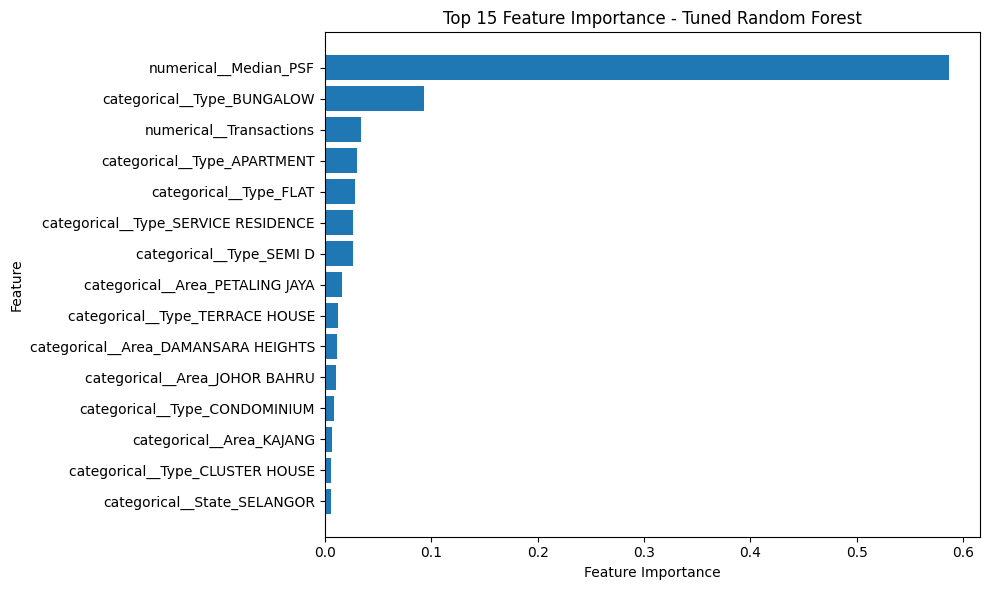

In [34]:
feature_names = preprocessor.get_feature_names_out()
feature_importance = tuned_rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

top_features = importance_df.head(15).sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance - Tuned Random Forest")

plt.tight_layout()

plt.savefig(
    'top_feature_tuned_random_forest.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

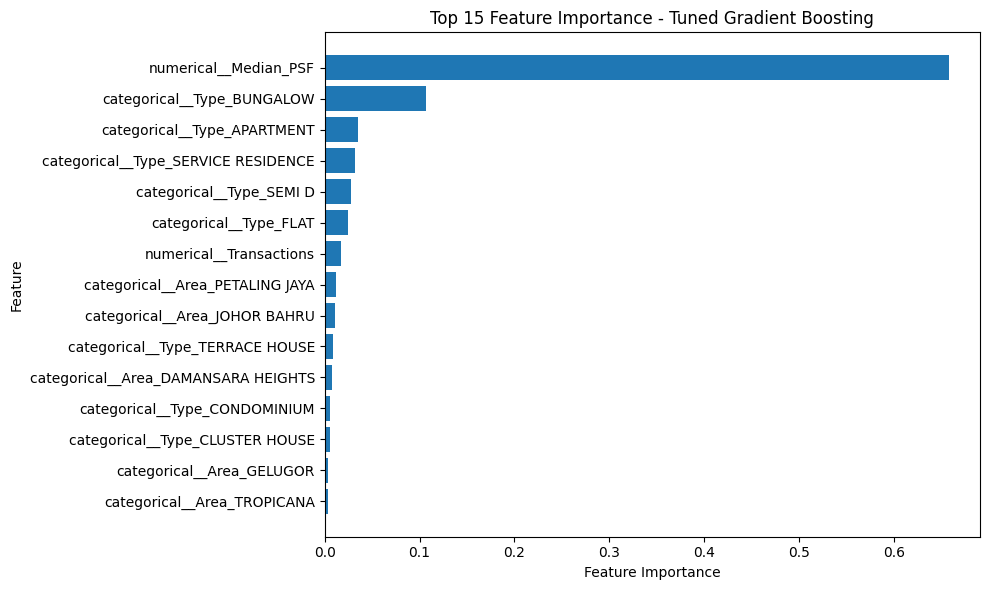

In [35]:
feature_names = preprocessor.get_feature_names_out()
feature_importance = tuned_gb_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

top_features = importance_df.head(15).sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance - Tuned Gradient Boosting")

plt.tight_layout()
plt.savefig(
    'top_feature_tuned_gradient_boosting.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

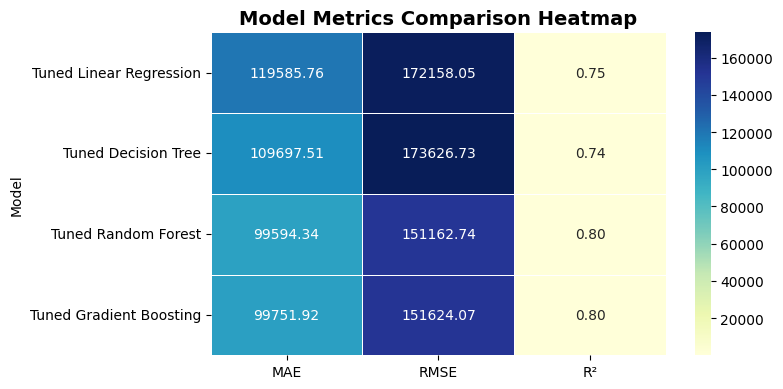

In [36]:
import seaborn as sns

heatmap_df = final_comparison.set_index('Model')

plt.figure(figsize=(8, 4))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="YlGnBu", cbar=True, linewidths=0.5)
plt.title("Model Metrics Comparison Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(
    'model_metrics_comparison.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [37]:
import joblib

model_bundle = {

    'preprocessor': preprocessor,
    'models': {
        'Linear Regression': tuned_linear_model,
        'Decision Tree': tuned_tree_model,
        'Random Forest': tuned_rf_model,
        'Gradient Boosting': tuned_gb_model
    },

    'metrics': {
        'Linear Regression': {
            'MAE': mae_tuned_linear,
            'MSE': mse_tuned_linear,
            'RMSE': rmse_tuned_linear,
            'R2': r2_tuned_linear
        },

        'Decision Tree': {
            'MAE': mae_tuned_tree,
            'MSE': mse_tuned_tree,
            'RMSE': rmse_tuned_tree,
            'R2': r2_tuned_tree
        },

        'Random Forest': {
            'MAE': mae_tuned_rf,
            'MSE': mse_tuned_rf,
            'RMSE': rmse_tuned_rf,
            'R2': r2_tuned_rf
        },

        'Gradient Boosting': {
            'MAE': mae_tuned_gb,
            'MSE': mse_tuned_gb,
            'RMSE': rmse_tuned_gb,
            'R2': r2_tuned_gb
        }

    }
}
joblib.dump(
    model_bundle,
    'malaysia_house_price_models.joblib'
)

print("====================================")
print("FINAL MODELS SAVED SUCCESSFULLY")
print("====================================")
print("File: malaysia_house_price_models.joblib")

print("Models saved:")
for model_name in model_bundle['models']:
    print("-", model_name)

FINAL MODELS SAVED SUCCESSFULLY
File: malaysia_house_price_models.joblib
Models saved:
- Linear Regression
- Decision Tree
- Random Forest
- Gradient Boosting


In [38]:
loaded_bundle = joblib.load('malaysia_house_price_models.joblib')

print("Model bundle loaded successfully!")
print("\nAvailable models:")
for model_name in loaded_bundle['models']:
    print("-", model_name)

print("\nStored metrics:")
print(pd.DataFrame(loaded_bundle['metrics']).T)

Model bundle loaded successfully!

Available models:
- Linear Regression
- Decision Tree
- Random Forest
- Gradient Boosting

Stored metrics:
                             MAE           MSE           RMSE        R2
Linear Regression  119585.762772  2.963839e+10  172158.047351  0.746815
Decision Tree      109697.509825  3.014624e+10  173626.726989  0.742477
Random Forest       99594.339347  2.285017e+10  151162.741810  0.804803
Gradient Boosting   99751.919344  2.298986e+10  151624.067618  0.803610
